# 统一评估结果分析

加载所有 ML + DL 模型的 `eval_results.json`，对比验证集（weekly）和滑动验证集（sliding）的 final_score 等指标。

In [27]:
import os, json, warnings
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

## 加载评估结果

In [28]:
RESULTS_FILE = "../output/eval_all_results.json"

if os.path.exists(RESULTS_FILE):
    df = pd.read_json(RESULTS_FILE, orient="records")
    print(f"Loaded {len(df)} experiments from {RESULTS_FILE}")
    if "kind" in df.columns:
        for k in ["dl", "ml", "ml_cv"]:
            n = len(df[df["kind"]==k])
            if n:
                print(f"  {k}: {n}")
else:
    import glob
    files = glob.glob("../model/**/eval_results.json", recursive=True)
    rows = []
    for f in files:
        with open(f) as fh:
            r = json.load(fh)
            r["exp_dir"] = str(Path(f).parent)
            rows.append(r)
    df = pd.DataFrame(rows) if rows else pd.DataFrame()
    print(f"Loaded {len(df)} experiments from individual eval_results.json")

display_cols = ["model_type", "kind", "weekly_score", "sliding_score",
                "weekly_ndcg", "sliding_ndcg", "weekly_hit_rate", "sliding_hit_rate"]
display_cols = [c for c in display_cols if c in df.columns]
if not df.empty:
    display(df[display_cols].sample(min(10, len(df))))


Loaded 2324 experiments from ../output/eval_all_results.json
  dl: 433
  ml: 4
  ml_cv: 1887


,model_type,kind,weekly_score,sliding_score,weekly_ndcg,sliding_ndcg,weekly_hit_rate,sliding_hit_rate
507,xgb,ml_cv,0.030649,0.030649,-0.056409,-0.056409,0.054167,0.054167
335,patchtst,dl,0.130901,0.136494,0.079760,-0.016170,0.083333,0.166667
992,xgb,ml_cv,0.054132,0.054132,-0.297833,-0.297833,0.154167,0.154167
1870,lightgbm,ml_cv,0.078470,0.078470,-0.156013,-0.156013,0.162500,0.162500
1975,lightgbm,ml_cv,0.106830,0.106830,-0.244344,-0.244344,0.154167,0.154167
1993,lightgbm,ml_cv,0.126929,0.126929,-0.137860,-0.137860,0.158333,0.158333
1057,xgb,ml_cv,0.057681,0.057681,-0.291156,-0.291156,0.145833,0.145833
1118,xgb,ml_cv,0.092188,0.092188,-0.318007,-0.318007,0.170833,0.170833
434,xgb,ml_cv,-0.009169,-0.009169,-0.158077,-0.158077,0.054167,0.054167
1317,xgb,ml_cv,0.138230,0.138230,-0.176230,-0.176230,0.158333,0.158333


## 验证指标相关性

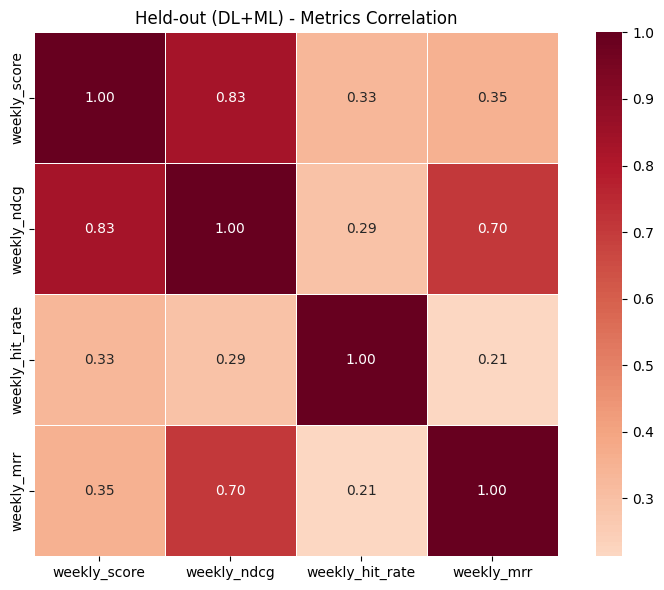

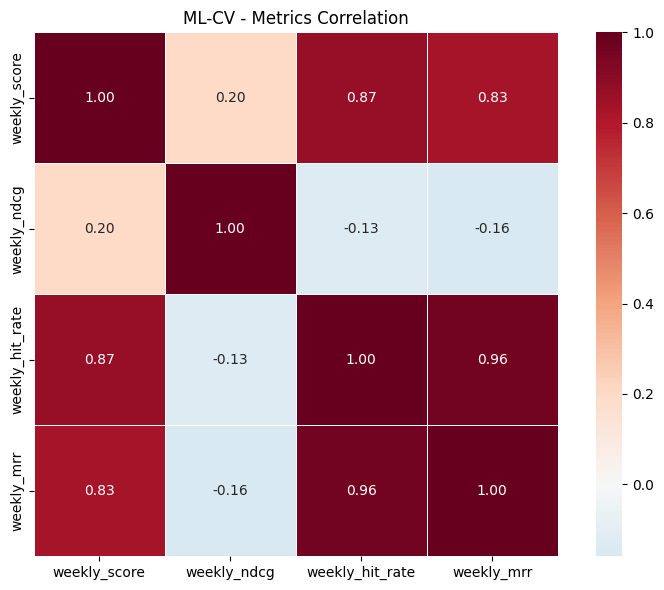

In [29]:
if not df.empty and "kind" in df.columns:
    held_out = df[df["kind"].isin(["dl", "ml"])]
    cv = df[df["kind"] == "ml_cv"]
    score_cols = ["weekly_score", "weekly_ndcg", "weekly_hit_rate", "weekly_mrr"]
    score_cols = [c for c in score_cols if c in df.columns]
    
    for sub, label in [(held_out, "Held-out (DL+ML)"), (cv, "ML-CV")]:
        if len(sub) < 2:
            continue
        corr = sub[score_cols].corr()
        plt.figure(figsize=(8, 6))
        sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
                    square=True, linewidths=0.5)
        plt.title(f"{label} - Metrics Correlation")
        plt.tight_layout()
        plt.show()


## 各指标 Top 10

In [30]:
if not df.empty and "kind" in df.columns:
    held_out = df[df["kind"].isin(["dl", "ml"])]
    cv = df[df["kind"] == "ml_cv"]
    metrics = ["weekly_score", "weekly_ndcg", "weekly_hit_rate", "weekly_mrr"]
    metrics = [m for m in metrics if m in df.columns]
    
    for label, sub in [("Held-out (DL+ML)", held_out), ("ML-CV", cv)]:
        if sub.empty:
            continue
        print(f"\n=== {label} ====")
        for m in metrics:
            top = sub.nlargest(min(10, len(sub)), m)
            print(f"\nTop 10 by {m}:")
            cols = ["model_type", "kind", m]
            if "search_method" in sub.columns:
                cols.insert(1, "search_method")
            display(top[cols].reset_index(drop=True))



=== Held-out (DL+ML) ====

Top 10 by weekly_score:


,model_type,search_method,kind,weekly_score
0,timesnet,bayes,dl,0.253435
1,timesnet,bayes,dl,0.225811
2,timesnet,bayes,dl,0.225811
3,timesnet,bayes,dl,0.221507
4,timesnet,bayes,dl,0.220853
5,dlinear,bayes,dl,0.219474
6,mamba,bayes,dl,0.215744
7,timesnet,bayes,dl,0.213905
8,timesnet,bayes,dl,0.213765
9,timesnet,bayes,dl,0.211291



Top 10 by weekly_ndcg:


,model_type,search_method,kind,weekly_ndcg
0,timesnet,bayes,dl,0.201974
1,timesnet,bayes,dl,0.200731
2,timesnet,bayes,dl,0.197768
3,patchtst,bayes,dl,0.197719
4,patchtst,bayes,dl,0.190063
5,timesnet,bayes,dl,0.181396
6,timesnet,bayes,dl,0.178588
7,timesnet,bayes,dl,0.176964
8,timesnet,bayes,dl,0.174021
9,timesnet,bayes,dl,0.167385



Top 10 by weekly_hit_rate:


...

,model_type,search_method,kind,weekly_ndcg
0,catboost,bayes,ml_cv,0.086264
1,catboost,bayes,ml_cv,0.075528
2,catboost,bayes,ml_cv,0.075260
3,catboost,bayes,ml_cv,0.064968
4,catboost,bayes,ml_cv,0.064599
5,catboost,bayes,ml_cv,0.058914
6,catboost,bayes,ml_cv,0.054230
7,catboost,bayes,ml_cv,0.053648
8,catboost,bayes,ml_cv,0.050433
9,catboost,bayes,ml_cv,0.049482



Top 10 by weekly_hit_rate:


,model_type,search_method,kind,weekly_hit_rate
0,lightgbm,grid,ml_cv,0.2375
1,lightgbm,grid,ml_cv,0.2375
2,lightgbm,grid,ml_cv,0.2375
3,lightgbm,grid,ml_cv,0.2375
4,lightgbm,grid,ml_cv,0.2375
5,lightgbm,grid,ml_cv,0.2375
6,lightgbm,grid,ml_cv,0.2250
7,lightgbm,grid,ml_cv,0.2250
8,lightgbm,grid,ml_cv,0.2250
9,lightgbm,grid,ml_cv,0.2250



Top 10 by weekly_mrr:


,model_type,search_method,kind,weekly_mrr
0,lightgbm,grid,ml_cv,0.473376
1,lightgbm,grid,ml_cv,0.473376
2,lightgbm,grid,ml_cv,0.473376
3,lightgbm,grid,ml_cv,0.473376
4,lightgbm,grid,ml_cv,0.473376
5,lightgbm,grid,ml_cv,0.473376
6,lightgbm,grid,ml_cv,0.460817
7,lightgbm,grid,ml_cv,0.460817
8,lightgbm,grid,ml_cv,0.460817
9,lightgbm,grid,ml_cv,0.460817


## 各模型类型统计

In [31]:
if not df.empty and "kind" in df.columns:
    for kind in ["dl", "ml", "ml_cv"]:
        sub = df[df["kind"] == kind]
        if sub.empty:
            continue
        label = "ML-CV (CV scores)" if kind == "ml_cv" else f"{kind.upper()} (held-out)"
        print(f"\n{label}")
        summary = sub.groupby("model_type").agg(
            count=("weekly_score", "count"),
            mean_score=("weekly_score", "mean"),
            max_score=("weekly_score", "max"),
            mean_ndcg=("weekly_ndcg", "mean"),
            mean_hit_rate=("weekly_hit_rate", "mean"),
            mean_mrr=("weekly_mrr", "mean"),
        ).round(4).sort_values("max_score", ascending=False)
        display(summary)
    
    # Best overall (held-out only)
    held_out = df[df["kind"].isin(["dl", "ml"])]
    if not held_out.empty:
        best = held_out.loc[held_out["sliding_score"].idxmax()]
        print(f"\nBest held-out: {best["model_type"]} ({best.get("kind", "?")})")
        print(f"  sliding_score={best["sliding_score"]:.4f}  weekly_score={best["weekly_score"]:.4f}")
        print(f"  ndcg={best.get("sliding_ndcg", 0):.4f}  hit_rate={best.get("sliding_hit_rate", 0):.4f}")



DL (held-out)


,count,mean_score,max_score,mean_ndcg,mean_hit_rate,mean_mrr
model_type,,,,,,
timesnet,78,0.1434,0.2534,0.1064,0.0839,0.8216
dlinear,82,0.0083,0.2195,-0.1521,0.0793,0.6534
mamba,80,0.0771,0.2157,-0.0243,0.0344,0.7266
itransformer,13,0.1057,0.1992,-0.0268,0.0705,0.6925
patchtst,116,0.0983,0.1976,0.0737,0.0826,0.8454
nlinear,64,0.1121,0.1969,-0.0291,0.0755,0.5811



ML (held-out)


,count,mean_score,max_score,mean_ndcg,mean_hit_rate,mean_mrr
model_type,,,,,,
xgb,2,0.1263,0.1508,0.0567,0.1280,0.6577
lightgbm,1,0.1501,0.1501,0.1146,0.1607,0.6875
catboost,1,0.1292,0.1292,0.0679,0.1131,0.6667



ML-CV (CV scores)


,count,mean_score,max_score,mean_ndcg,mean_hit_rate,mean_mrr
model_type,,,,,,
lightgbm,757,0.1267,0.2199,-0.1520,0.1765,0.3581
xgb,1051,0.0538,0.1975,-0.1874,0.1127,0.2569
catboost,79,0.0633,0.1230,-0.0020,0.0466,0.1495



Best held-out: timesnet (dl)
  sliding_score=0.3318  weekly_score=0.1704
  ndcg=0.1814  hit_rate=0.2273


## 参数重要性分析

In [32]:
if not df.empty:
    param_cols = [c for c in ["learning_rate", "max_depth", "subsample",
                               "colsample_bytree", "l2_reg", "num_leaves",
                               "min_data_in_leaf", "min_child_weight",
                               "d_model", "num_layers", "dropout"] if c in df.columns]
    if param_cols:
        for kind in df["kind"].unique():
            sub = df[df["kind"] == kind]
            for mt in sub["model_type"].unique():
                sub2 = sub[sub["model_type"] == mt]
                avail = [c for c in param_cols if c in sub2.columns and sub2[c].notna().any()]
                if not avail or len(sub2) < 2:
                    continue
                print(f"\n[{kind}] {mt.upper()} - Top 5 by score:")
                top = sub2.nlargest(min(5, len(sub2)), "weekly_score")
                for _, r in top.iterrows():
                    ps = " | ".join(f"{k}={r[k]}" for k in avail)
                    print(f"  score={r["weekly_score"]:.4f} ndcg={r["weekly_ndcg"]:.4f} | {ps}")
    else:
        print("No parameter columns found in eval results.")



[ml_cv] XGB - Top 5 by score:
  score=0.1975 ndcg=-0.0842 | learning_rate=0.05 | max_depth=8.0 | subsample=0.8 | colsample_bytree=1.0 | l2_reg=1.0 | num_leaves=31.0 | min_data_in_leaf=10.0 | min_child_weight=nan
  score=0.1975 ndcg=-0.0842 | learning_rate=0.05 | max_depth=8.0 | subsample=0.8 | colsample_bytree=1.0 | l2_reg=1.0 | num_leaves=31.0 | min_data_in_leaf=50.0 | min_child_weight=nan
  score=0.1975 ndcg=-0.0842 | learning_rate=0.05 | max_depth=8.0 | subsample=0.8 | colsample_bytree=1.0 | l2_reg=1.0 | num_leaves=31.0 | min_data_in_leaf=100.0 | min_child_weight=nan
  score=0.1975 ndcg=-0.0842 | learning_rate=0.05 | max_depth=8.0 | subsample=1.0 | colsample_bytree=1.0 | l2_reg=1.0 | num_leaves=31.0 | min_data_in_leaf=10.0 | min_child_weight=nan
  score=0.1975 ndcg=-0.0842 | learning_rate=0.05 | max_depth=8.0 | subsample=1.0 | colsample_bytree=1.0 | l2_reg=1.0 | num_leaves=31.0 | min_data_in_leaf=50.0 | min_child_weight=nan

[ml_cv] LIGHTGBM - Top 5 by score:
  score=0.2199 ndcg=0.

## 最佳模型预测可视化

In [33]:
def plot_metrics(preds, targets, title_prefix=""):
    if len(preds) == 0 or len(targets) == 0:
        return
    n = min(len(preds), len(targets))
    preds, targets = preds[:n], targets[:n]
    k = 3
    topk_pred = np.argsort(-preds, axis=1)[:, :k]
    topk_actual = np.argsort(-targets, axis=1)[:, :k]

    pred_returns = np.array([targets[i, topk_pred[i]].sum() for i in range(n)])
    actual_returns = np.array([targets[i, topk_actual[i]].sum() for i in range(n)])

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    ax = axes[0]
    for data, label, style in [(pred_returns, "Predicted TopK", "-"),
                                 (actual_returns, "Actual TopK", "-")]:
        ax.plot(np.cumsum(data), style, label=label)
    ax.set_title(f"{title_prefix} Cumulative Return")
    ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[1]
    for data, label in [(pred_returns, "Predicted"), (actual_returns, "Actual")]:
        ax.hist(data, bins=30, alpha=0.5, label=label)
    ax.set_title(f"{title_prefix} Distribution")
    ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[2]
    hits = (topk_pred == topk_actual).sum(axis=1) / k
    ax.bar(range(len(hits)), hits, alpha=0.6)
    ax.axhline(y=hits.mean(), color="red", linestyle="--", label=f"Mean: {hits.mean():.3f}")
    ax.set_title(f"{title_prefix} Daily Hit Rate@{k}")
    ax.legend(); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

if not df.empty and "exp_dir" in df.columns and "kind" in df.columns:
    held_out = df[df["kind"].isin(["dl", "ml"])]
    if not held_out.empty:
        best = held_out.loc[held_out["sliding_score"].idxmax()]
        exp_dir = best["exp_dir"]
        kind = best.get("kind", "dl")
        print(f"Best model: {best["model_type"]} at {exp_dir}")
        print(f"  sliding_score={best["sliding_score"]:.4f}  weekly_score={best["weekly_score"]:.4f}")

        if kind == "dl":
            pred_files = {
                "weekly": os.path.join(exp_dir, "preds_weekly_epoch1.npy"),
                "sliding": os.path.join(exp_dir, "preds_sliding_epoch1.npy"),
            }
            target_files = {
                "weekly": os.path.join(exp_dir, "targets_weekly.npy"),
                "sliding": os.path.join(exp_dir, "targets_sliding.npy"),
            }
        else:
            pred_files = {
                "weekly": os.path.join(exp_dir, "final", "preds_weekly.npy"),
                "sliding": os.path.join(exp_dir, "final", "preds_sliding.npy"),
            }
            target_files = {
                "weekly": os.path.join(exp_dir, "final", "targets_weekly.npy"),
                "sliding": os.path.join(exp_dir, "final", "targets_sliding.npy"),
            }

        for k in ["weekly", "sliding"]:
            if os.path.exists(pred_files[k]) and os.path.exists(target_files[k]):
                preds = np.load(pred_files[k])
                targets = np.load(target_files[k])
                plot_metrics(preds, targets, f"{k.upper()}")
            else:
                print(f"  No {k} prediction files found")


Best model: timesnet at C:\Users\xyl\Desktop\ETF\code\src\..\..\model\bayes_timesnet_74_3_2026-01-01_2026-03-31\exp_64
  sliding_score=0.3318  weekly_score=0.1704
  No weekly prediction files found
  No sliding prediction files found


## 总结

In [34]:
if not df.empty:
    print("=" * 60)
    print("Summary")
    print("=" * 60)
    print(f"Total experiments: {len(df)}")
    if "kind" in df.columns:
        for k in ["dl", "ml", "ml_cv"]:
            n = len(df[df["kind"]==k])
            if n:
                print(f"  {k}: {n}")
    
    held_out = df[df["kind"].isin(["dl", "ml"])] if "kind" in df.columns else df
    if not held_out.empty:
        print(f"\nHeld-out best sliding_score: {held_out["sliding_score"].max():.4f}")
        print(f"Held-out best weekly_score:  {held_out["weekly_score"].max():.4f}")
        print(f"Held-out mean sliding_score: {held_out["sliding_score"].mean():.4f}")
        print(f"Held-out mean weekly_score:  {held_out["weekly_score"].mean():.4f}")
    
    cv = df[df["kind"]=="ml_cv"] if "kind" in df.columns else pd.DataFrame()
    if not cv.empty:
        print(f"\nML-CV best score:  {cv["weekly_score"].max():.4f}")
        print(f"ML-CV mean score:  {cv["weekly_score"].mean():.4f}")


Summary
Total experiments: 2324
  dl: 433
  ml: 4
  ml_cv: 1887

Held-out best sliding_score: 0.3318
Held-out best weekly_score:  0.2534
Held-out mean sliding_score: 0.1475
Held-out mean weekly_score:  0.0881

ML-CV best score:  0.2199
ML-CV mean score:  0.0834
